<a href="https://colab.research.google.com/github/ValeriaZav26/Customer-Churn-Prediction-/blob/main/Customer_Churn_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [140]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [141]:
df.shape

(7043, 21)

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [174]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [175]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [144]:
df.duplicated().sum()

np.int64(0)

In [145]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [146]:
df = df.drop(columns = ['customerID'] )

In [147]:
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn",]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [148]:
cols = ['OnlineBackup', 'OnlineSecurity', 'DeviceProtection', 'TechSupport',	'StreamingTV',	'StreamingMovies']

for col in cols:
  df[col] = df[col].map(
    {'Yes': 1, 'No': 0, 'No internet service': 0}
)

In [149]:
df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})

In [150]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,0,DSL,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,Male,0,0,0,34,1,0,DSL,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,Male,0,0,0,2,1,0,DSL,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,Male,0,0,0,45,0,0,DSL,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,1,1,24,1,1,DSL,1,0,1,1,1,1,One year,1,Mailed check,84.80,1990.5,0
7039,Female,0,1,1,72,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Credit card (automatic),103.20,7362.9,0
7040,Female,0,1,1,11,0,0,DSL,1,0,0,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,0
7041,Male,1,1,0,4,1,1,Fiber optic,0,0,0,0,0,0,Month-to-month,1,Mailed check,74.40,306.6,1


In [151]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,object
OnlineSecurity,int64
OnlineBackup,int64


In [152]:
int_columns = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

for i in int_columns:
  df[i] = df[i].astype(int)

In [153]:
df.describe()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,0.265370
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,1.000000


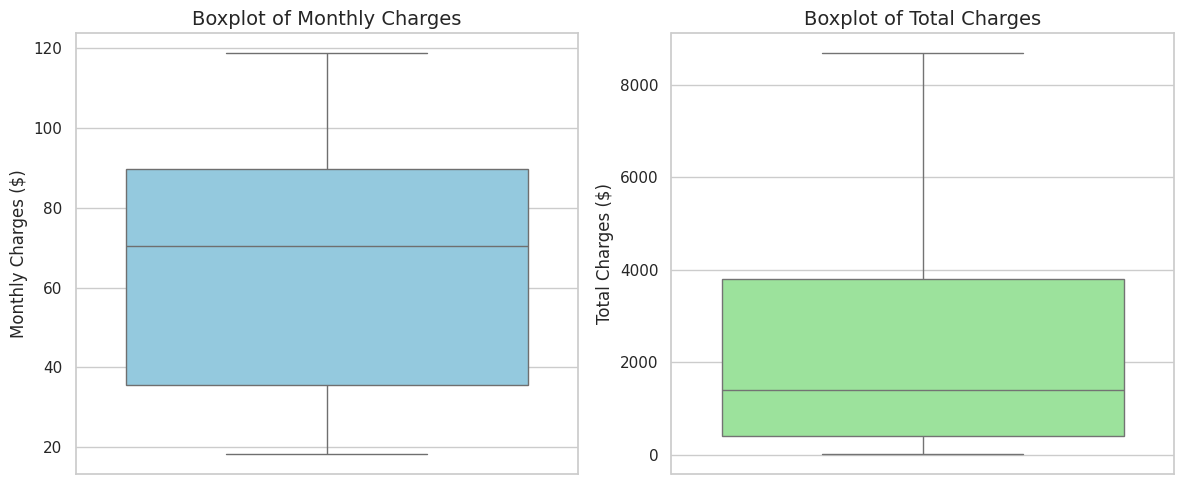

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["MonthlyCharges"], ax=axes[0], color="skyblue")
axes[0].set_title("Boxplot of Monthly Charges", fontsize=14)
axes[0].set_ylabel("Monthly Charges ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[1], color="lightgreen")
axes[1].set_title("Boxplot of Total Charges", fontsize=14)
axes[1].set_ylabel("Total Charges ($)")

plt.tight_layout()
plt.show()

Payments are distributed relatively evenly without outliers, with a median of around 70$ and half of the customers paying within the range of $35 to $90.

In [155]:
churn_counts = df["Churn"].value_counts()
churn_rates = df["Churn"].value_counts(normalize=True) * 100

print("--- Target Variable Distribution (Churn) ---")
for val in churn_counts.index:
  print(
      f"Class '{val}': {churn_counts[val]} clients"
      f" ({churn_rates[val]:.2f}%)"
  )

--- Target Variable Distribution (Churn) ---
Class '0': 5174 clients (73.46%)
Class '1': 1869 clients (26.54%)


In [156]:
# Filter churned customers
churned_df = df[df['Churn'] == 1]

# Calculate percentages in a single line for each feature
senior_pct = churned_df['SeniorCitizen'].mean() * 100
partner_pct = churned_df['Partner'].mean() * 100

print(f'Percentage of senior citizens among churned: {senior_pct:.2f}%')
print(
    f'Percentage of customers with a partner among churned: {partner_pct:.2f}%'
)

Percentage of senior citizens among churned: 25.47%
Percentage of customers with a partner among churned: 35.79%


In [157]:
paymentMethod_churn = (
    df.groupby('PaymentMethod')['Churn']
    .apply(lambda x: (x == 1).mean() * 100)
    .round(2)
    .reset_index(name='Churn_Rate_Percent')
)

print(paymentMethod_churn)

               PaymentMethod  Churn_Rate_Percent
0  Bank transfer (automatic)               16.71
1    Credit card (automatic)               15.24
2           Electronic check               45.29
3               Mailed check               19.11


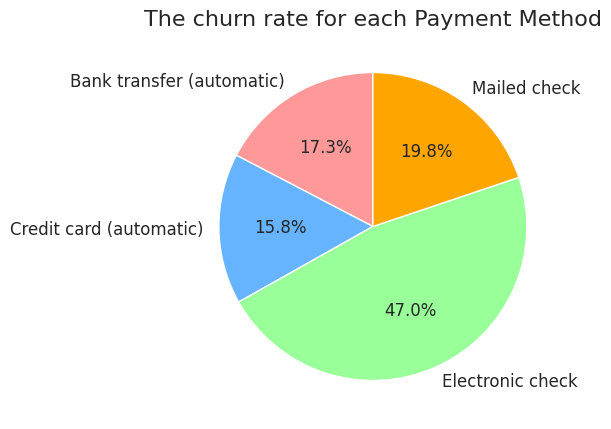

In [158]:
plt.figure(figsize=(5, 5))


paymentMethod_churn.set_index("PaymentMethod")["Churn_Rate_Percent"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    fontsize=12,
    ylabel="",
    colors=["#ff9999", "#66b3ff", "#99ff99", "#ffa500"]
)
plt.title("The churn rate for each Payment Method", fontsize=16)
plt.show()


###Customers using Electronic Check were the most likely to cancel their service.
### Customers who paid via Mailed Check, Automatic Bank Transfer, or Credit Card (automatic transfer) were significantly less likely to leave.

In [159]:
# Calculate the churn rate for each contract type
contract_churn = (
    df.groupby('Contract')['Churn']
    .apply(lambda x: (x == 1).mean() * 100)
    .round(2)
    .reset_index(name='Churn_Rate_Percent')
)

print(contract_churn)

         Contract  Churn_Rate_Percent
0  Month-to-month               42.71
1        One year               11.27
2        Two year                2.83


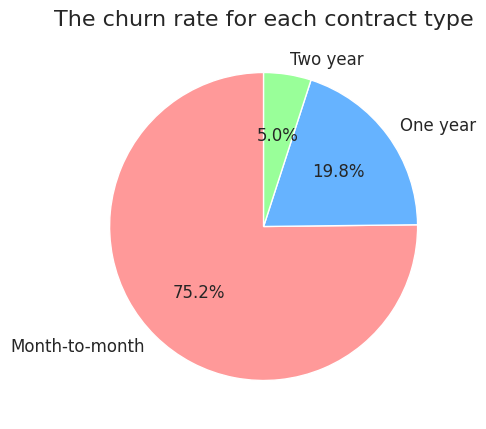

In [160]:
plt.figure(figsize=(5, 5))


contract_churn.set_index("Contract")["Churn_Rate_Percent"].plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    fontsize=12,
    ylabel="",
    colors=["#ff9999", "#66b3ff", "#99ff99"]
)
plt.title("The churn rate for each contract type", fontsize=16)
plt.show()

###Customer churn is heavily concentrated in month-to-month contracts (75.2%), whereas one-year (19.8%) and two-year (5.0%) contracts experience significantly lower churn.

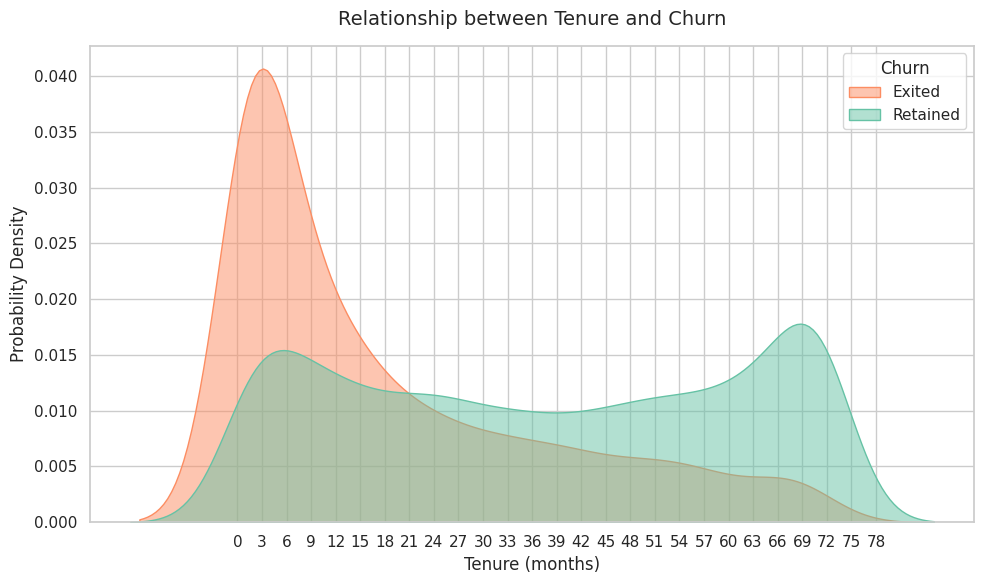

In [161]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="tenure",
    hue="Churn",
    common_norm=False,
    fill=True,
    palette="Set2",
    alpha=0.5,
)

plt.xticks(np.arange(0, 80, 3))

plt.title(
    "Relationship between Tenure and Churn",
    fontsize=14,
    pad=15,
)
plt.xlabel("Tenure (months)", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)

plt.legend(title="Churn", labels=["Exited", "Retained"])

plt.tight_layout()
plt.show()

###The maximum density of churned customers occurs in the first few months, with a peak around 3 months

In [162]:
corr_matrix = df.select_dtypes(include=["number"]).corr()
corr_matrix

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.016479,-0.211185,0.016567,0.008576,0.142948,-0.038653,0.066572,0.059428,-0.060625,0.105378,0.120176,0.156530,0.220173,0.102411,0.150889
Partner,0.016479,1.000000,0.452676,0.379697,0.017706,0.142057,0.143106,0.141498,0.153786,0.119999,0.124666,0.117412,-0.014877,0.096848,0.319072,-0.150448
Dependents,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024526,0.080972,0.023671,0.013963,0.063268,-0.016558,-0.039741,-0.111377,-0.113890,0.064653,-0.164221
tenure,0.016567,0.379697,0.159712,1.000000,0.008448,0.331941,0.327203,0.360277,0.360653,0.324221,0.279756,0.286111,0.006152,0.247900,0.825880,-0.352229
PhoneService,0.008576,0.017706,-0.001762,0.008448,1.000000,0.279690,-0.092893,-0.052312,-0.071227,-0.096340,-0.022574,-0.032959,0.016505,0.247398,0.113008,0.011942
MultipleLines,0.142948,0.142057,-0.024526,0.331941,0.279690,1.000000,0.098108,0.202237,0.201137,0.100571,0.257152,0.258751,0.163530,0.490434,0.469042,0.040102
OnlineSecurity,-0.038653,0.143106,0.080972,0.327203,-0.092893,0.098108,1.000000,0.283832,0.275438,0.354931,0.176207,0.187398,-0.003636,0.296594,0.412619,-0.171226
OnlineBackup,0.066572,0.141498,0.023671,0.360277,-0.052312,0.202237,0.283832,1.000000,0.303546,0.294233,0.282106,0.274501,0.126735,0.441780,0.510100,-0.082255
DeviceProtection,0.059428,0.153786,0.013963,0.360653,-0.071227,0.201137,0.275438,0.303546,1.000000,0.333313,0.390874,0.402111,0.103797,0.482692,0.522881,-0.066160
TechSupport,-0.060625,0.119999,0.063268,0.324221,-0.096340,0.100571,0.354931,0.294233,0.333313,1.000000,0.278070,0.279358,0.037880,0.338304,0.432868,-0.164674


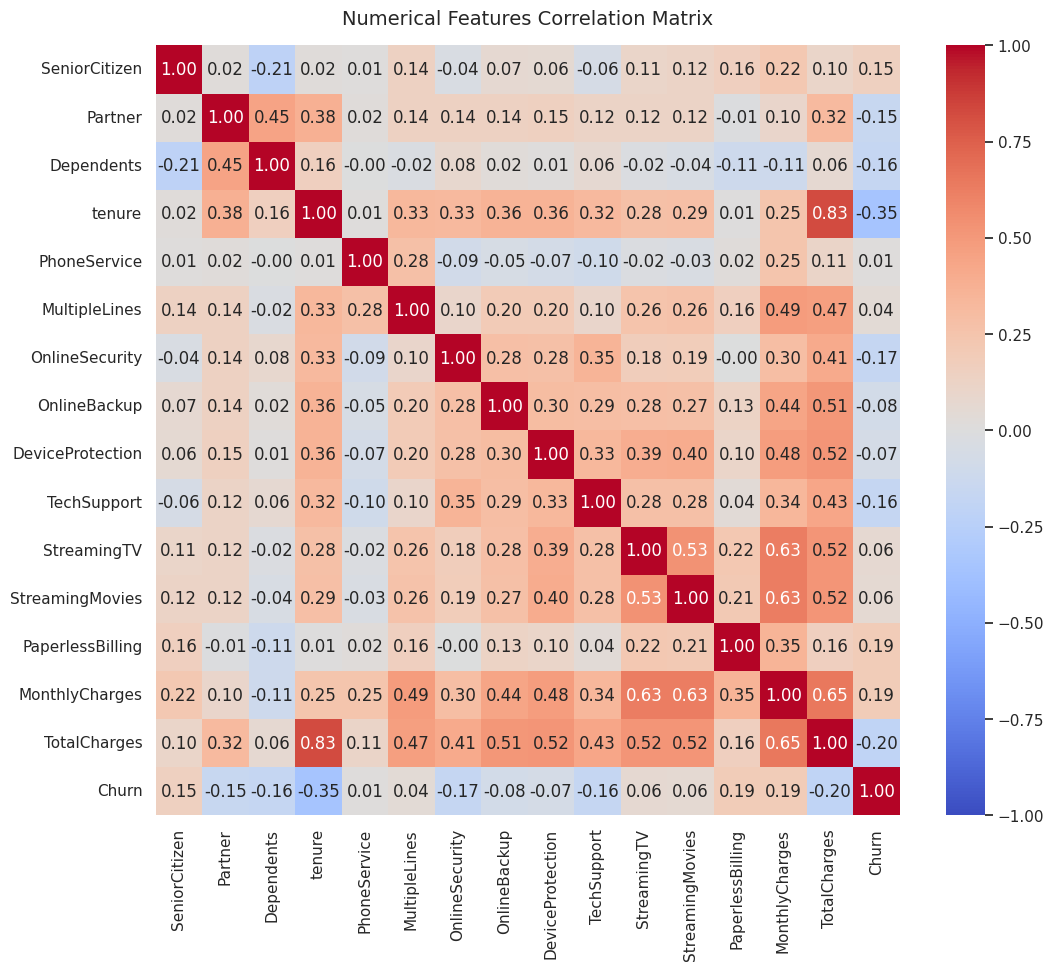

In [163]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1
)
plt.title("Numerical Features Correlation Matrix", fontsize=14, pad=15)
plt.show()

###1) Tenure has the strongest negative correlation with churn (-0.35), confirming the critical importance of early-stage customer retention.   
###2) High monthly charges (MonthlyCharges) increase churn (0.19), whereas total accumulated expenses (TotalCharges) correlate with long-term stability (-0.20).
###3) The presence of security services (OnlineSecurity) and tech support significantly increases customer loyalty.   
###4) Senior citizens (SeniorCitizen) and paperless billing users (PaperlessBilling) are in the high-risk zone, while having family (Partner, Dependents) reduces the likelihood of churn.

#Machine Learning Model Evaluations and Predictions

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split


In [166]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, test_size=0.2, random_state=0
)

In [167]:
low_cardinality_cols = [
    cname for cname in X_train if X_train[cname].nunique() <= 10 and X_train[cname].dtype == 'object'
]

numerical_cols = [
    cname for cname in X_train if X_train[cname].dtype in ['int64', 'float']
]

In [168]:
def evaluate_model(name, model, X_train, y_train, X_valid, y_valid):
    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred = model.predict(X_valid)

    metrics = {
        "model": name,
        "train_roc_auc": roc_auc_score(y_train, train_proba),
        "valid_roc_auc": roc_auc_score(y_valid, valid_proba),
        "valid_pr_auc": average_precision_score(y_valid, valid_proba),
    }

    print(f"--- {name} ---")
    print(f"Train ROC-AUC: {metrics['train_roc_auc']:.4f}")
    print(f"Valid ROC-AUC: {metrics['valid_roc_auc']:.4f}")
    print(f"Valid PR-AUC:  {metrics['valid_pr_auc']:.4f}")
    print(classification_report(y_valid, valid_pred, digits=3))

    return metrics


##1.RandomForestClassifier

In [169]:
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, low_cardinality_cols),
        ('num', numeric_transformer, numerical_cols)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=0))
])

rf_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_leaf': [1, 5, 10],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', None],
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("Best params (RF):", rf_grid.best_params_)
print("Best CV ROC-AUC:", round(rf_grid.best_score_, 4))

Best params (RF): {'model__class_weight': None, 'model__max_depth': 15, 'model__max_features': 'log2', 'model__min_samples_leaf': 10, 'model__n_estimators': 300}
Best CV ROC-AUC: 0.8513


In [170]:
rf_metrics = evaluate_model("RandomForest", rf_grid.best_estimator_,
                             X_train, y_train, X_valid, y_valid)

--- RandomForest ---
Train ROC-AUC: 0.9015
Valid ROC-AUC: 0.8315
Valid PR-AUC:  0.6344
              precision    recall  f1-score   support

           0      0.832     0.906     0.867      1041
           1      0.644     0.481     0.551       368

    accuracy                          0.795      1409
   macro avg      0.738     0.693     0.709      1409
weighted avg      0.782     0.795     0.784      1409



##2.XGBClassifier

In [172]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=0, eval_metric='logloss'))
])

xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_lambda': [1, 5],
    'model__scale_pos_weight': [1, scale_pos_weight],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)
print("Best params (XGB):", xgb_grid.best_params_)
print("Best CV ROC-AUC:", round(xgb_grid.best_score_, 4))

scale_pos_weight: 2.753
Best params (XGB): {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__reg_lambda': 5, 'model__scale_pos_weight': 1, 'model__subsample': 0.8}
Best CV ROC-AUC: 0.8529


In [173]:
xgb_metrics = evaluate_model("XGBClassifier", xgb_grid.best_estimator_,
                             X_train, y_train, X_valid, y_valid)

--- XGBClassifier ---
Train ROC-AUC: 0.8674
Valid ROC-AUC: 0.8288
Valid PR-AUC:  0.6326
              precision    recall  f1-score   support

           0      0.831     0.904     0.866      1041
           1      0.639     0.481     0.549       368

    accuracy                          0.793      1409
   macro avg      0.735     0.692     0.707      1409
weighted avg      0.781     0.793     0.783      1409




###XGBoost and RandomForest showed similar validation performance (ROC-AUC 0.83), but XGBoost has  less overfitting (overfit gap 0.039 vs. 0.070 for RF) we select XGBoost. Recall for the "Churn" class is low (~0.48) — the model misses more than half of churning customers. For retention campaigns, it's worth lowering the classification threshold.
